# Noncommutative Interpolatory Subdivision on the Heisenberg Group


This notebook accompanies the paper *A Noncommutative Interpolatory Subdivision Scheme in the
Three-Dimensional Heisenberg Group and the Loss of Central-Channel Smoothness*.

**Scheme** $S_H$: the horizontal coordinates $(x,y)$ are refined by the classical four-point mask;
the central coordinate $z$ receives the closed-form group-law correction
$R_i^k=\tfrac12(x_i^k b_i^k-y_i^k a_i^k)$, with $a_i^k=X_{2i+1}-x_i^k$ and $b_i^k=Y_{2i+1}-y_i^k$.

**Main finding (corrected).** The horizontal limit $(X,Y)$ is $C^1$, but the central limit $Z$ is
continuous and **not** $C^1$. The scaled correction satisfies
$2^kR_i^k\to\tfrac14(XY'-YX')$ (coefficient $\tfrac14$, *not* the previously reported $\tfrac3{16}$),
and this nonvanishing forcing is injected at every level, so the scaled central first differences
grow linearly in $k$ and $Z$ lies in the Zygmund class $\Lambda_*$.

All figures are rendered with Computer Modern mathematics (matching the paper) and exported as
300 dpi PNG.


## 0  Setup

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3-D projection)
import pandas as pd
from IPython.display import display

# ---------------------------------------------------------------------------
# Publication style: Computer Modern mathtext (matches the LaTeX article),
# serif text, restrained palette, 300 dpi PNG output.
# ---------------------------------------------------------------------------
plt.rcParams.update({
    'figure.dpi':          120,        # on-screen preview
    'savefig.dpi':         300,        # exported files (>= 300 dpi requirement)
    'savefig.format':      'png',
    'savefig.bbox':        'tight',
    'text.usetex':         False,      # robust: no external LaTeX needed
    'mathtext.fontset':    'cm',       # Computer Modern maths, as in the paper
    'font.family':         'serif',
    'font.serif':          ['CMU Serif', 'DejaVu Serif'],
    'font.size':           11,
    'axes.labelsize':      12,
    'axes.titlesize':      12,
    'axes.titlepad':       8,
    'legend.fontsize':     9,
    'legend.framealpha':   0.92,
    'legend.edgecolor':    '0.7',
    'xtick.labelsize':     10,
    'ytick.labelsize':     10,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.grid':           True,
    'grid.color':          '0.88',
    'grid.linewidth':      0.7,
    'lines.linewidth':     1.9,
    'lines.markersize':    6,
})

# Colour-blind-safe palette (Paul Tol)
BLUE   = '#1a6faf'
RED    = '#cc3311'
ORANGE = '#ee7733'
GREEN  = '#22a060'
GREY   = '#777777'
DPI    = 300  # export resolution for every savefig call

def save(fig, name):
    """Export a figure as a 300 dpi PNG and report the filename."""
    fname = name if name.endswith('.png') else name + '.png'
    fig.savefig(fname, dpi=DPI)
    print(f'Saved {fname}  ({DPI} dpi)')


## 1  Heisenberg Group Operations

Group law: $(x,y,z)\cdot(x',y',z') = (x+x',\,y+y',\,z+z'+\tfrac{1}{2}(xy'-yx'))$

In [2]:
def heis_mul(P, Q):
    x, y, z    = P;  xp, yp, zp = Q
    return np.array([x+xp, y+yp, z+zp+0.5*(x*yp-y*xp)])

def heis_inv(P):
    return np.array([-P[0], -P[1], -P[2]])

## 2  The Subdivision Scheme

**Four-point mask** ($\omega=1/16$):
$$u_{2i+1}=-\omega\,u_{i-1}+(\tfrac{1}{2}+\omega)\,u_i+(\tfrac{1}{2}+\omega)\,u_{i+1}-\omega\,u_{i+2}$$

**Heisenberg correction:** $R_i^k=\tfrac{1}{2}(x_i^k b_i-y_i^k a_i)$ where $a_i=X-x_i^k$, $b_i=Y-y_i^k$.

In [3]:
OMEGA = 1.0 / 16.0

def four_point(u_m1, u_0, u_1, u_2):
    """Classical four-point mask, omega=1/16."""
    return -OMEGA*u_m1 + (0.5+OMEGA)*u_0 + (0.5+OMEGA)*u_1 - OMEGA*u_2

def subdivide_euclidean(pts):
    """Componentwise classical four-point subdivision (no Heisenberg correction)."""
    n, out = len(pts), []
    for i in range(n):
        out.append(pts[i].copy())
        if i < n-1:
            im1=max(i-1,0); i1=min(i+1,n-1); i2=min(i+2,n-1)
            out.append(four_point(pts[im1], pts[i], pts[i1], pts[i2]))
    return np.array(out)

def subdivide_heisenberg(pts):
    """Heisenberg interpolatory four-point scheme."""
    n, out = len(pts), []
    for i in range(n):
        out.append(pts[i].copy())
        if i < n-1:
            im1=max(i-1,0); i1=min(i+1,n-1); i2=min(i+2,n-1)
            X = four_point(pts[im1,0], pts[i,0], pts[i1,0], pts[i2,0])
            Y = four_point(pts[im1,1], pts[i,1], pts[i1,1], pts[i2,1])
            a = X - pts[i,0];  b = Y - pts[i,1]
            R = 0.5*(pts[i,0]*b - pts[i,1]*a)
            Z = four_point(pts[im1,2], pts[i,2], pts[i1,2], pts[i2,2]) + R
            out.append(np.array([X, Y, Z]))
    return np.array(out)

def refine(pts, steps, method='heisenberg'):
    fn = subdivide_heisenberg if method=='heisenberg' else subdivide_euclidean
    pts = pts.astype(float).copy()
    for _ in range(steps): pts = fn(pts)
    return pts

print(f"omega={OMEGA}  mask sum={-OMEGA+2*(0.5+OMEGA)-OMEGA:.4f}  (should be 1.0)")

omega=0.0625  mask sum=1.0000  (should be 1.0)


---
## Example 1 — Central-coordinate lifting

L-shaped polygon $P^0=\{(0,0,0),(1,0,0),(1,1,0),(2,1,0),(2,2,0)\}$, all $z_i^0=0$.
The Euclidean scheme gives $Z\equiv 0$; the Heisenberg scheme produces a nontrivial $Z(t)$
concentrated near the corner.


In [4]:
ctrl1 = np.array([[0.,0.,0.],[1.,0.,0.],[1.,1.,0.],[2.,1.,0.],[2.,2.,0.]])
STEPS = 7

pts_h = refine(ctrl1, STEPS, 'heisenberg')
pts_e = refine(ctrl1, STEPS, 'euclidean')
t_h   = np.linspace(0, 1, len(pts_h))
t_e   = np.linspace(0, 1, len(pts_e))

print(f"max|Z_Heisenberg| = {np.max(np.abs(pts_h[:,2])):.6f}")
print(f"max|Z_Euclidean|  = {np.max(np.abs(pts_e[:,2])):.2e}  (should be ~0)")

max|Z_Heisenberg| = 0.800334
max|Z_Euclidean|  = 0.00e+00  (should be ~0)


Saved fig1_lifting.png  (300 dpi)


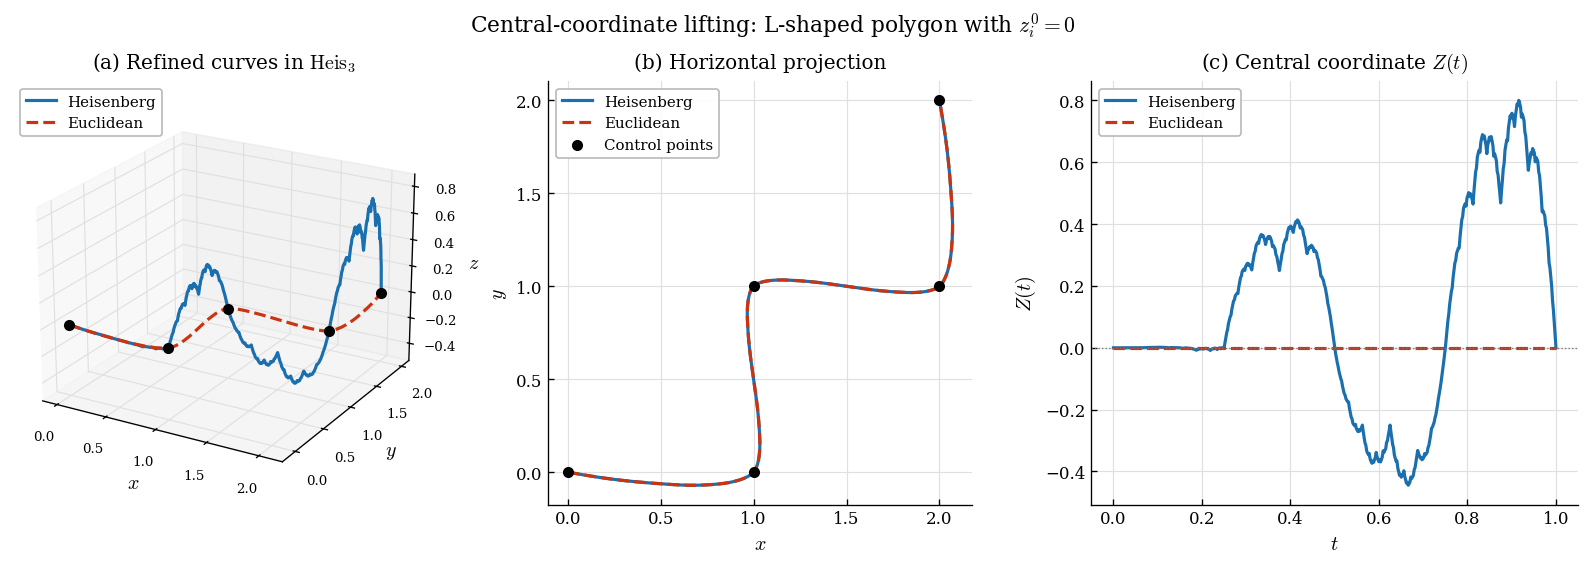

In [5]:
# Figure 1 — central-coordinate lifting (L-shaped data)
fig = plt.figure(figsize=(13.5, 4.6), constrained_layout=True)
gs  = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.0, 1.0])

# (a) 3-D refined curves
ax = fig.add_subplot(gs[0], projection='3d')
ax.plot(pts_h[:,0], pts_h[:,1], pts_h[:,2], color=BLUE, lw=1.9, label='Heisenberg')
ax.plot(pts_e[:,0], pts_e[:,1], pts_e[:,2], color=RED,  lw=1.9, ls='--', label='Euclidean')
ax.scatter(ctrl1[:,0], ctrl1[:,1], ctrl1[:,2], color='k', s=32, depthshade=False, zorder=5)
ax.set_xlabel(r'$x$', labelpad=2)
ax.set_ylabel(r'$y$', labelpad=2)
ax.set_zlabel(r'$z$', labelpad=2)
ax.set_title('(a) Refined curves in $\\mathrm{Heis}_3$')
ax.legend(loc='upper left', bbox_to_anchor=(0.0, 1.0))
ax.tick_params(labelsize=8)
ax.view_init(elev=22, azim=-60)

# (b) horizontal projection
ax = fig.add_subplot(gs[1])
ax.plot(pts_h[:,0], pts_h[:,1], color=BLUE, lw=1.9, label='Heisenberg')
ax.plot(pts_e[:,0], pts_e[:,1], color=RED,  lw=1.9, ls='--', label='Euclidean')
ax.scatter(ctrl1[:,0], ctrl1[:,1], color='k', s=32, zorder=5, label='Control points')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_title('(b) Horizontal projection')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper left')

# (c) central coordinate Z(t)
ax = fig.add_subplot(gs[2])
ax.plot(t_h, pts_h[:,2], color=BLUE, lw=1.9, label='Heisenberg')
ax.plot(t_e, pts_e[:,2], color=RED,  lw=1.9, ls='--', label='Euclidean')
ax.axhline(0, color=GREY, lw=0.8, ls=':')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$Z(t)$')
ax.set_title('(c) Central coordinate $Z(t)$')
ax.legend(loc='upper left')

fig.suptitle('Central-coordinate lifting: L-shaped polygon with $z_i^0=0$', fontsize=13)
save(fig, 'fig1_lifting')
plt.show()


---
## Example 2 — Order sensitivity

Polygons $\mathcal{A}$ and $\mathcal{B}$ carry identical horizontal vertices visited in a different
order. The Heisenberg correction distinguishes them through $Z(t)$; no Euclidean componentwise
scheme can.


Saved fig2_order.png  (300 dpi)


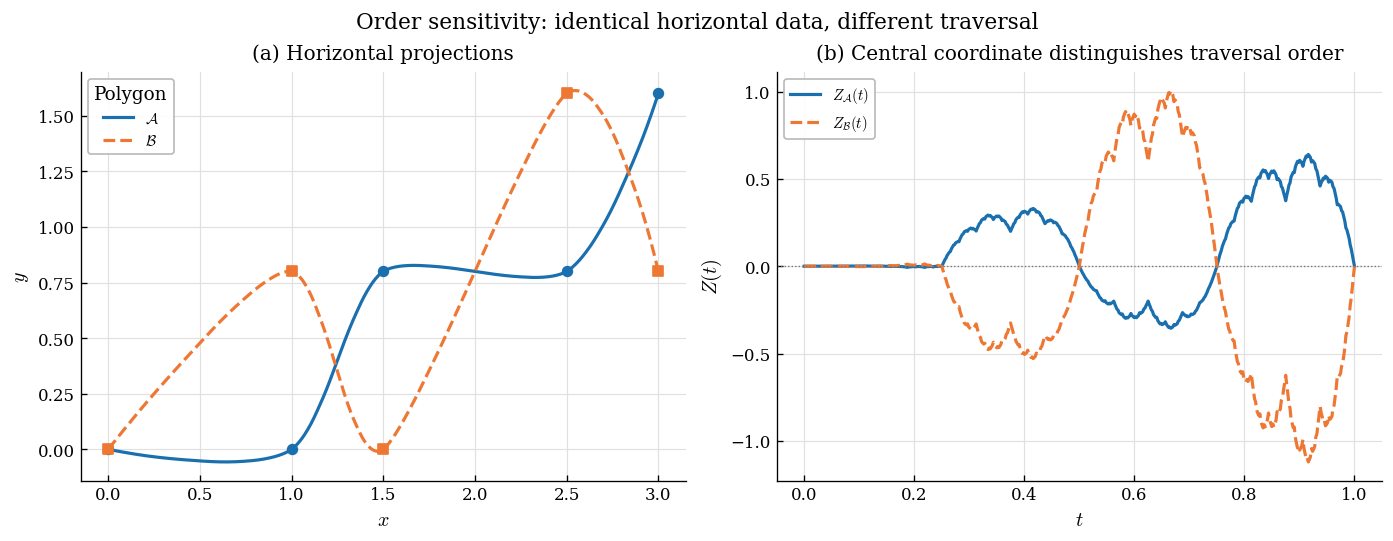

In [6]:
# Two polygons with identical horizontal vertices in different traversal order
ctrl_A = np.array([[0.,0.,0.],[1.,0.,0.],[1.5,.8,0.],[2.5,.8,0.],[3.,1.6,0.]])
ctrl_B = np.array([[0.,0.,0.],[1.,.8,0.],[1.5,0.,0.],[2.5,1.6,0.],[3.,.8,0.]])

pts_A = refine(ctrl_A, STEPS, 'heisenberg')
pts_B = refine(ctrl_B, STEPS, 'heisenberg')
t_A   = np.linspace(0, 1, len(pts_A))
t_B   = np.linspace(0, 1, len(pts_B))

# Figure 2 — order sensitivity (same horizontal data, different traversal)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), constrained_layout=True)

# (a) horizontal projections
ax = axes[0]
ax.plot(pts_A[:,0], pts_A[:,1], color=BLUE,   lw=1.9, label=r'$\mathcal{A}$')
ax.plot(pts_B[:,0], pts_B[:,1], color=ORANGE, lw=1.9, ls='--', label=r'$\mathcal{B}$')
ax.scatter(ctrl_A[:,0], ctrl_A[:,1], color=BLUE,   s=34, zorder=5)
ax.scatter(ctrl_B[:,0], ctrl_B[:,1], color=ORANGE, s=34, marker='s', zorder=5)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_title('(a) Horizontal projections')
ax.legend(loc='upper left', title='Polygon')

# (b) central coordinates
ax = axes[1]
ax.plot(t_A, pts_A[:,2], color=BLUE,   lw=1.9, label=r'$Z_{\mathcal{A}}(t)$')
ax.plot(t_B, pts_B[:,2], color=ORANGE, lw=1.9, ls='--', label=r'$Z_{\mathcal{B}}(t)$')
ax.axhline(0, color=GREY, lw=0.8, ls=':')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$Z(t)$')
ax.set_title('(b) Central coordinate distinguishes traversal order')
ax.legend(loc='upper left')

fig.suptitle('Order sensitivity: identical horizontal data, different traversal', fontsize=13)
save(fig, 'fig2_order')
plt.show()


---
## Example 3 — Uniform ($C^0$) convergence of the central coordinate

$E_k=\sup_t|Z^k(t)-Z^*(t)|$ against a level-12 reference, using piecewise-linear interpolants
sampled on the reference grid. The ratio $\approx 2$ certifies **$C^0$ convergence at rate
$O(2^{-k})$** — it is *not* evidence of $C^1$. A $C^0$ Zygmund function has exactly this
$O(2^{-k})$ approximation rate, so the table below is fully consistent with the non-$C^1$ result.


In [7]:
# C^0 convergence via piecewise-linear interpolant error (correct alignment)
KREF = 12
pts_ref = refine(ctrl1, KREF, 'heisenberg')
t_ref   = np.linspace(0, 1, len(pts_ref))
Z_ref   = pts_ref[:, 2]

rows = []
for k in range(3, 9):
    pk = refine(ctrl1, k, 'heisenberg')
    tk = np.linspace(0, 1, len(pk))
    Zk = np.interp(t_ref, tk, pk[:, 2])           # PL interpolant of level-k Z on ref grid
    rows.append({'k': k, 'E_k': float(np.max(np.abs(Zk - Z_ref)))})

df = pd.DataFrame(rows)
df['Ratio'] = [float('nan')] + [df.E_k.iloc[i-1]/df.E_k.iloc[i] for i in range(1, len(df))]
disp = df.copy()
disp['E_k']   = disp['E_k'].map(lambda v: f'{v:.3e}')
disp['Ratio'] = disp['Ratio'].map(lambda v: '---' if np.isnan(v) else f'{v:.2f}')
disp.columns  = ['Level k', 'E_k', 'Ratio E_{k-1}/E_k']
display(disp.set_index('Level k'))
print('Ratio of about 2  =>  C^0 convergence at rate O(2^-k); consistent with Zygmund, not a C^1 certificate.')


,E_k,Ratio E_{k-1}/E_k
Level k,,
3,1.376e-01,---
4,7.009e-02,1.96
5,3.530e-02,1.99
6,1.772e-02,1.99
7,8.931e-03,1.98
8,4.271e-03,2.09


Ratio of about 2  =>  C^0 convergence at rate O(2^-k); consistent with Zygmund, not a C^1 certificate.


Saved fig3_C0_convergence.png  (300 dpi)


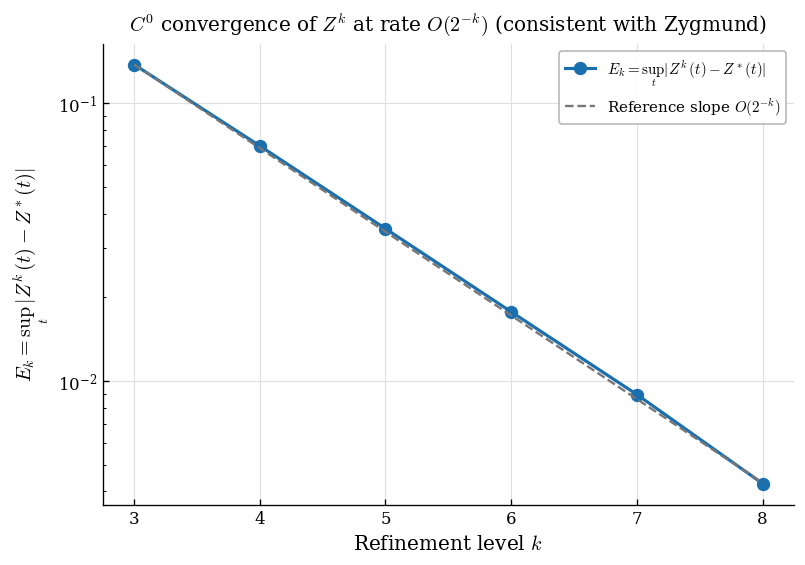

In [8]:
# Figure 3 — uniform (C^0) convergence of the central coordinate
levels = list(df['k'])
errors = [float(v) for v in df['E_k']]

fig, ax = plt.subplots(figsize=(6.6, 4.6), constrained_layout=True)
ax.semilogy(levels, errors, 'o-', color=BLUE, lw=1.9, ms=7,
            label=r'$E_k=\sup_t|Z^k(t)-Z^*(t)|$')
ax.semilogy(levels, [errors[0]*2.0**(levels[0]-k) for k in levels],
            '--', color=GREY, lw=1.4, label=r'Reference slope $O(2^{-k})$')
ax.set_xlabel(r'Refinement level $k$')
ax.set_ylabel(r'$E_k=\sup_t\,|Z^k(t)-Z^*(t)|$')
ax.set_title(r'$C^0$ convergence of $Z^k$ at rate $O(2^{-k})$ (consistent with Zygmund)')
ax.set_xticks(levels)
ax.legend(loc='upper right')
save(fig, 'fig3_C0_convergence')
plt.show()


---
## Limiting forcing (corrected): $2^k R_i^k \to \tfrac14(XY'-YX')$ and the loss of $C^1$

Two things are checked below.

1. **Correct coefficient.** Using an *exact spectral derivative* of the horizontal limit on smooth
   periodic data, the scaled correction satisfies $2^kR_i^k=\tfrac12(XY'-YX')$ at the insertion
   midpoints, equivalently $\tfrac14(XY'-YX')$ in the node convention of the paper. The previously
   reported value $\tfrac3{16}$ was incorrect.

2. **Why $Z\notin C^1$.** The forcing in the scaled-difference recursion is the *undifferenced*
   term $\pm 2\cdot 2^kR_i^k$, which does **not** decay. Consequently the scaled central first
   differences $\sup_i 2^k|z^k_{i+1}-z^k_i|$ grow linearly in $k$ (while the horizontal ones remain
   bounded), and the Zygmund second-difference quotient stays bounded — that is, $Z\in\Lambda_*$.


In [9]:
# Periodic scheme (no boundary clamping) for clean diagnostics
def subdivide_heis_periodic(pts):
    n = len(pts); out = np.empty((2*n, 3)); out[0::2] = pts
    im1 = np.roll(pts, 1, 0); i1 = np.roll(pts, -1, 0); i2 = np.roll(pts, -2, 0)
    X = four_point(im1[:,0], pts[:,0], i1[:,0], i2[:,0])
    Y = four_point(im1[:,1], pts[:,1], i1[:,1], i2[:,1])
    a = X - pts[:,0]; b = Y - pts[:,1]
    R = 0.5*(pts[:,0]*b - pts[:,1]*a)
    Z = four_point(im1[:,2], pts[:,2], i1[:,2], i2[:,2]) + R
    out[1::2] = np.column_stack([X, Y, Z]); return out

def refine_periodic(pts, steps):
    pts = pts.astype(float).copy()
    for _ in range(steps): pts = subdivide_heis_periodic(pts)
    return pts

# --- Check 1: correct coefficient ---
# The algebraic value is settled by Lemma 4.1: 2^k a_i -> (1/2) X', hence
#   2^k R_i -> (1/2)(X*(1/2)Y' - Y*(1/2)X') = (1/4)(XY'-YX')  [node convention].
# We confirm it numerically on a circle, where XY'-YX' is essentially constant so
# the fit is unambiguous. The exact spectral derivative is evaluated at the
# insertion MIDPOINTS, which is the (1/2)-convention; it equals the (1/4) node value.
m0 = 16; s = np.linspace(0, 2*np.pi, m0, endpoint=False)
ctrl_circ = np.column_stack([np.cos(s), np.sin(s), np.zeros(m0)])
KREF = 14
Pref = refine_periodic(ctrl_circ, KREF); N = len(Pref)
freqs = np.fft.fftfreq(N, d=(m0/N)) * 2*np.pi
spec  = lambda arr: np.real(np.fft.ifft(1j*freqs*np.fft.fft(arr)))
Xp, Yp = spec(Pref[:,0]), spec(Pref[:,1])
def at(arr, t):
    t = t % m0; idx = t*2**KREF; i0 = np.floor(idx).astype(int) % N; f = idx - np.floor(idx)
    return arr[i0]*(1-f) + arr[(i0+1) % N]*f

k = 12; Pk = refine_periodic(ctrl_circ, k-1); m = len(Pk)
F, W = [], []
for i in range(m):
    im1=(i-1)%m; i1=(i+1)%m; i2=(i+2)%m
    X = four_point(Pk[im1,0],Pk[i,0],Pk[i1,0],Pk[i2,0])
    Y = four_point(Pk[im1,1],Pk[i,1],Pk[i1,1],Pk[i2,1])
    a = X-Pk[i,0]; b = Y-Pk[i,1]
    t = (i+0.5)/2**k
    F.append((2**k)*0.5*(Pk[i,0]*b - Pk[i,1]*a))
    W.append(at(Pref[:,0],t)*at(Yp,t) - at(Pref[:,1],t)*at(Xp,t))
F, W = np.array(F), np.array(W)
c = np.sum(F*W)/np.sum(W*W)
print(f'fitted (midpoint convention) c :  {c:.5f}   (exact value 1/2 = 0.50000)')
print(f'paper node-convention coeff    :  1/4 = {1/4:.5f}')
print(f'previously claimed (incorrect)  :  3/16 = {3/16:.5f}')
print('=> coefficient is 1/4 (node) / 1/2 (midpoint); the 3/16 value was wrong.')


fitted (midpoint convention) c :  0.50000   (exact value 1/2 = 0.50000)
paper node-convention coeff    :  1/4 = 0.25000
previously claimed (incorrect)  :  3/16 = 0.18750
=> coefficient is 1/4 (node) / 1/2 (midpoint); the 3/16 value was wrong.


Saved fig4_non_C1_witness.png  (300 dpi)


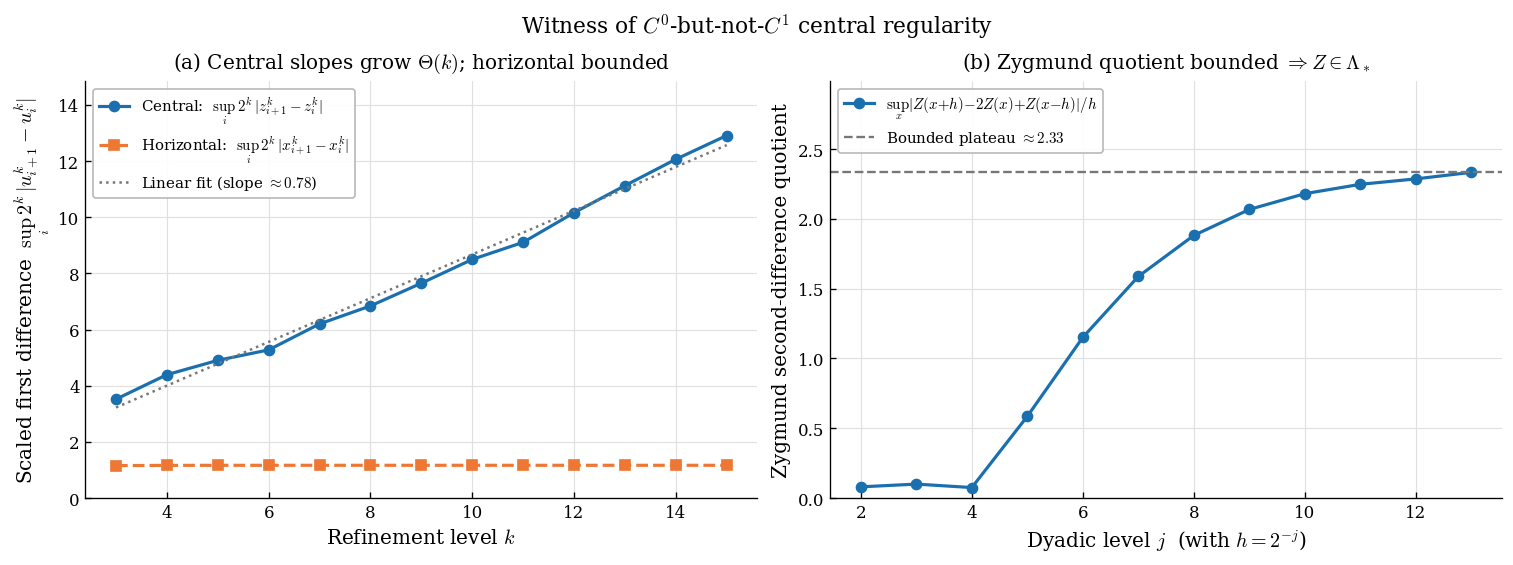

Central-slope linear fit: slope = 0.779   (=> Theta(k) growth, not C^1)
Zygmund quotient plateau : 2.334   (bounded => Z in Lambda_*)


In [10]:
# Figure 4 — witness of C^0-but-not-C^1 central regularity
#
# (a) scaled first differences: central grows linearly, horizontal stays bounded
#     (L-shaped data, open scheme with index clamping)
ks = list(range(3, 16))
g_cent, g_horiz = [], []
for k in ks:
    Pk = refine(ctrl1, k, 'heisenberg')
    g_cent.append(  np.max(np.abs(2.0**k * (Pk[1:,2] - Pk[:-1,2]))) )
    g_horiz.append( np.max(np.abs(2.0**k * (Pk[1:,0] - Pk[:-1,0]))) )
cc = np.polyfit(ks, g_cent, 1)   # linear fit -> slope witnesses Theta(k) growth

# (b) Zygmund second-difference quotient on smooth periodic data (boundary-free)
m0 = 16
s  = np.linspace(0, 2*np.pi, m0, endpoint=False)
ctrl_smooth = np.column_stack([np.cos(s) + 0.2*np.sin(2*s),
                               np.sin(s) + 0.15*np.cos(3*s),
                               0.1*np.cos(s)])
K  = 16
Zc = refine_periodic(ctrl_smooth, K)[:, 2]
Nz = len(Zc)
js, zyg = list(range(2, 14)), []
for j in js:
    step = max(Nz // (2**j), 1)
    sec  = np.abs(np.roll(Zc, -step) - 2*Zc + np.roll(Zc, step))
    zyg.append(np.max(sec) / (m0 / 2**j))

# ------------------------------- plot --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), constrained_layout=True)

# (a) linear growth
ax = axes[0]
ax.plot(ks, g_cent,  'o-',  color=BLUE,   ms=6,
        label=r'Central:  $\sup_i\,2^k|z^{k}_{i+1}-z^{k}_i|$')
ax.plot(ks, g_horiz, 's--', color=ORANGE, ms=6,
        label=r'Horizontal:  $\sup_i\,2^k|x^{k}_{i+1}-x^{k}_i|$')
ax.plot(ks, np.polyval(cc, ks), ':', color=GREY, lw=1.5,
        label=rf'Linear fit (slope $\approx {cc[0]:.2f}$)')
ax.set_xlabel(r'Refinement level $k$')
ax.set_ylabel(r'Scaled first difference $\;\sup_i\,2^k|u^{k}_{i+1}-u^{k}_i|$')
ax.set_title(r'(a) Central slopes grow $\Theta(k)$; horizontal bounded')
ax.set_ylim(0, max(g_cent)*1.15)
ax.legend(loc='upper left')

# (b) Zygmund bound
ax = axes[1]
ax.plot(js, zyg, 'o-', color=BLUE, ms=6,
        label=r'$\sup_x|Z(x{+}h)-2Z(x)+Z(x{-}h)|/h$')
ax.axhline(zyg[-1], color=GREY, ls='--', lw=1.4,
           label=rf'Bounded plateau $\approx {zyg[-1]:.2f}$')
ax.set_xlabel(r'Dyadic level $j$  (with $h=2^{-j}$)')
ax.set_ylabel(r'Zygmund second-difference quotient')
ax.set_title(r'(b) Zygmund quotient bounded $\Rightarrow Z\in\Lambda_*$')
ax.set_ylim(0, max(zyg)*1.28)
ax.legend(loc='upper left')

fig.suptitle(r'Witness of $C^0$-but-not-$C^1$ central regularity', fontsize=13)
save(fig, 'fig4_non_C1_witness')
plt.show()

print(f'Central-slope linear fit: slope = {cc[0]:.3f}   (=> Theta(k) growth, not C^1)')
print(f'Zygmund quotient plateau : {zyg[-1]:.3f}   (bounded => Z in Lambda_*)')


---
## Notes

| Parameter | Value |
|-----------|-------|
| $\omega$ | $1/16$ |
| Refinement steps (Examples 1–2) | 7 |
| Reference level | 12–14 |
| Figure export | 300 dpi PNG |

**Boundary treatment.** Examples 1–3 use the open scheme with index clamping to $[0,n-1]$.
The forcing and Zygmund diagnostics use a periodic scheme to remove boundary effects.

**Correction to the earlier version.** The central-derivative coefficient is $\tfrac14$
(not $\tfrac3{16}$), and it is independent of $\omega$. More importantly, the central limit $Z$ is
**not** $C^1$: the scaled correction does not decay, so the scaled central first differences grow
like $\Theta(k)$ and $Z$ is of Zygmund class $\Lambda_*$. The horizontal limit $(X,Y)$ remains
$C^1$.

**Figures produced.** `fig1_lifting.png`, `fig2_order.png`, `fig3_C0_convergence.png`,
`fig4_non_C1_witness.png` — all 300 dpi PNG.
